# Learning 4 Robotics Expierments

In this lab you will train a robot to run by **watching an expert** — no hand-coded rules, no reward engineering. The technique is called **Behavior Cloning**:

1. An expert policy runs the robot; we record what it sees and does.
2. We treat those recordings as a supervised dataset: **input = observation, label = action**.
3. We train a small neural network (MLP) to predict the expert's actions.
4. We deploy our learned policy and compare it to the expert.

The robot is **HalfCheetah** from MuJoCo — a 2D simulated cheetah that learns to run forward.

---

## ⚙️ Setup — read this before running anything


### ☁️ Running on Google Colab

**1. Switch to a GPU runtime:**
> Runtime → Change runtime type → Hardware accelerator → **T4 GPU** → Save

**2. Run Step 0 first** and wait for `✅ Setup complete`.



## Step 0 — Colab Setup ☁️

> **Local users: skip this cell.**  
> **Colab users: run this cell first** and wait for `✅ Setup complete`.

In [41]:
# ════════════════════════════════════════════════
# COLAB ONLY — local users skip this cell
# ════════════════════════════════════════════════
import subprocess, sys, os

REPO = 'pgss-L4R-IL-public'
if not os.path.isdir(REPO):
    r = subprocess.run(['git', 'clone', 'https://github.com/alokshah04/pgss-L4R-IL-public.git'],
                       capture_output=True, text=True)
    print(r.stdout or r.stderr)
else:
    print('Repo already cloned.')
if not os.getcwd().endswith(REPO):
    os.chdir(REPO)
print('Working directory:', os.getcwd())

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'], check=True)
print('\n✅ Setup complete. Continue to Step 1.')

Repo already cloned.
Working directory: /Users/NiravShah/Downloads/pgss-L4R-RL/pgss-L4R-IL-public

✅ Setup complete. Continue to Step 1.


In [42]:
#import subprocess, sys, os
#this is jakes stuff
#print(subprocess.run(['git', 'clone', 'https://github.com/vwxyzjn/cleanrl.git'], capture_output=True, text=True).stdout)
#print(subprocess.run(['cd', 'cleanrl']).stdout)
#print(subprocess.run(['uv', 'pip', 'install', '.']).stdout)

---
## Step 1 — Imports and Expert 💻☁️

*(You may see a `Could not deserialize lr_schedule` warning — harmless. The policy weights load fine.)*

In [1]:
import gymnasium as gym
from stable_baselines3 import SAC
import imageio
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import Video, display

ENV_NAME    = 'HalfCheetah-v5'
EXPERT_PATH = 'experts/HalfCheetah-v5'

expert = SAC.load(EXPERT_PATH)
print('Expert policy loaded.')

env = gym.make(ENV_NAME)
print(f'Observation space: {env.observation_space}')   # what the robot sees
print(f'Action space:      {env.action_space}')        # what the robot does
env.close()

C:\Users\jakew\miniconda3\Lib\site-packages\stable_baselines3\common\save_util.py:167: UserWarning: Could not deserialize object lr_schedule. Consider using `custom_objects` argument to replace this object.
Exception: code() argument 13 must be str, not int
  warnings.warn(


Expert policy loaded.
Observation space: Box(-inf, inf, (17,), float64)
Action space:      Box(-1.0, 1.0, (6,), float32)


In [43]:
%pip install gymnasium
%pip install stable_baselines3
%pip install imageio
%pip install numpy
%pip install torch
%pip install matplotlib
%pip install tqdm
%pip install IPython
%pip install gymnasium[mujoco]

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Step 1a — Video recorder 💻 (local only)

> **Colab users: skip Steps 1a and 1b.** Video rendering requires a display, which Colab does not have.

We use gymnasium's built-in `rgb_array` renderer to record frames.

In [ ]:
# ════════════════════════════════════════════════
# LOCAL ONLY — Colab users skip this cell
# ════════════════════════════════════════════════
def record_policy(step_fn, env_name, path, max_steps=300, seed=1, fps=30):
    """Run step_fn(obs) -> action and save an MP4 using gymnasium's rgb_array renderer."""
    env = gym.make(env_name, render_mode='rgb_array')
    obs, _ = env.reset(seed=seed)
    frames, total_reward = [], 0.0
    for _ in range(max_steps):
        action = step_fn(obs)
        obs, reward, done, truncated, _ = env.step(action)
        total_reward += reward
        frames.append(env.render())
        if done or truncated:
            break
    env.close()
    imageio.mimsave(path, frames, fps=fps)
    print(f'Saved {path}  |  reward: {total_reward:.1f}  |  frames: {len(frames)}')
    return total_reward

print('record_policy defined.')

### Step 1b — Watch the expert run 💻 (local only)

> **Colab users: skip this cell.**

In [20]:
# ════════════════════════════════════════════════
# LOCAL ONLY — Colab users skip this cell
# ════════════════════════════════════════════════
def expert_step(obs):
    action, _ = expert.predict(obs, deterministic=True)
    return action

record_policy(expert_step, ENV_NAME, 'data/shrink_and_perturb/expert_demo.mp4')
display(Video('data/shrink_and_perturb/expert_demo.mp4', embed=True, width=600))

ValueError: Could not find a backend to open `expert_demo.mp4`` with iomode `wI`.
Based on the extension, the following plugins might add capable backends:
  FFMPEG:  pip install imageio[ffmpeg]
  pyav:  pip install imageio[pyav]

In [ ]:
def learned_step(obs):
    action = model(torch.tensor(obs).float())
    return action.detach().cpu().numpy()

record_policy(learned_step, ENV_NAME, 'data/shrink_and_perturb/learned_policy_demo.mp4')
display(Video('data/shrink_and_perturb/learned_policy_demo.mp4', embed=True, width=600))

---
## Step 2 — Collect Demonstrations 💻☁️

We roll out the expert many times and store every *(observation, action)* pair it produces.

Each **trajectory** is a dictionary with three lists:
```
{
  'obs'     : [o_0, o_1, ..., o_T],   # what the robot saw at each step
  'acts'    : [a_0, a_1, ..., a_T],   # what the expert did at each step
  'rewards' : [r_0, r_1, ..., r_T],   # reward received at each step
}
```

We collect `NUM_TRAJ` trajectories in total, then split them **70 / 10** into a **training set** and a **validation set**. The model only sees the training set during gradient updates; the validation set is used to check that it generalises to unseen data.

In [2]:
NUM_TRAJ      = 80
MAX_TIMESTEPS = 300
VAL_TRAJ      = 10   # held-out trajectories for validation

print(f'Collecting {NUM_TRAJ} expert trajectories...')

env = gym.make(ENV_NAME)
policy = SAC.load(EXPERT_PATH)
env.reset(seed=714)

all_trajectories = []
for ep in range(NUM_TRAJ):
    obs, _ = env.reset()
    traj = {'obs': [], 'acts': [], 'rewards': []}
    for _ in range(MAX_TIMESTEPS):
        traj['obs'].append(obs.copy())
        action, _ = policy.predict(obs, deterministic=True)
        traj['acts'].append(action)
        obs, reward, done, truncated, _ = env.step(action)
        traj['rewards'].append(reward)
        if done or truncated:
            break
    all_trajectories.append(traj)
env.close()

# Split into train and val
train_trajs = all_trajectories[:NUM_TRAJ - VAL_TRAJ]
val_trajs   = all_trajectories[NUM_TRAJ - VAL_TRAJ:]

print(f'Train trajectories: {len(train_trajs)}')
print(f'Val   trajectories: {len(val_trajs)}')

C:\Users\jakew\miniconda3\Lib\site-packages\stable_baselines3\common\save_util.py:167: UserWarning: Could not deserialize object lr_schedule. Consider using `custom_objects` argument to replace this object.
Exception: code() argument 13 must be str, not int
  warnings.warn(


Train trajectories: 70
Val   trajectories: 10


In [3]:
# Inspect one trajectory
traj0 = train_trajs[0]
obs0, acts0 = np.array(traj0['obs']), np.array(traj0['acts'])
print(f'Trajectory length: {len(traj0["obs"])} steps')
print(f'Observation shape: {obs0.shape}  (T x obs_dim)')
print(f'Action shape:      {acts0.shape}  (T x act_dim)')
print(f'Total reward:      {sum(traj0["rewards"]):.1f}')
print('\nFirst observation (what the robot sees at t=0):')
print(obs0[0])
print('\nFirst expert action (what the expert does at t=0):')
print(acts0[0])

Trajectory length: 300 steps
Observation shape: (300, 17)  (T x obs_dim)
Action shape:      (300, 6)  (T x act_dim)
Total reward:      3042.4

First observation (what the robot sees at t=0):
[ 0.07979849 -0.09968245  0.0802322  -0.00894182  0.03409585  0.07366279
 -0.03158125  0.05782747 -0.15187879  0.08607435 -0.03188791 -0.0342352
  0.01386375  0.07561676 -0.01761814 -0.11691685 -0.0291773 ]

First expert action (what the expert does at t=0):
[ 0.68069696 -0.32595986  0.33129573 -0.9344946  -0.8046259  -0.8268681 ]


# ---
## Step 3 — Build a Supervised Learning Dataset 💻☁️

We flatten all trajectories into a flat list of *(observation, action)* pairs — exactly like any supervised learning problem:
- **Input X** = observation vector (17 numbers: joint angles & velocities)
- **Label Y** = action vector (6 numbers: one torque per joint)

We do this separately for the train and validation splits, then wrap each in a PyTorch `DataLoader` that handles batching and shuffling.

In [4]:
# ── Observation normalization shared by IL and PPO ───────────────────────────
# The reference CleanRL PPO wraps the env in NormalizeObservation, so the policy
# always sees ~zero-mean/unit-var observations. For the IL warm start to be valid
# in that PPO, the IL policy must be trained on the SAME normalized observations.
# We compute a FIXED mean/std once from the expert demonstrations (train split
# only) and reuse it verbatim: in IL training here, and as a frozen
# TransformObservation in the PPO env later. Fixed (not a running estimate) =
# reproducible and drift-free, so the obs distribution the IL actor learned is
# exactly the one PPO feeds it.
_all_obs = np.concatenate([np.array(t['obs']) for t in train_trajs], axis=0)
OBS_MEAN = _all_obs.mean(axis=0).astype(np.float32)
OBS_STD  = (_all_obs.std(axis=0) + 1e-8).astype(np.float32)
print(f'Obs normalization from demos: mean[:3]={OBS_MEAN[:3]}, std[:3]={OBS_STD[:3]}') # note to self: normalizes in each input dimension independently

def normalize_obs(obs):
    """Fixed demo-derived normalization, then clip to +/-10 (matches the reference)."""
    return np.clip((np.asarray(obs, dtype=np.float32) - OBS_MEAN) / OBS_STD, -10.0, 10.0)


class TrajDataset(Dataset):
    """
    Converts a list of trajectories into a PyTorch Dataset of (obs, action) pairs.
    Observations are NORMALIZED with the fixed demo statistics so the learned
    policy lives in the same input space the PPO env will later provide.
    """
    def __init__(self, trajectories):
        obs_list, act_list = [], []
        for traj in trajectories:
            obs_list.extend(traj['obs'])
            act_list.extend(traj['acts'])
        obs_arr = normalize_obs(np.array(obs_list))
        self.inputs = torch.tensor(obs_arr, dtype=torch.float32)
        self.labels = torch.tensor(np.array(act_list), dtype=torch.float32)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.labels[idx]


BATCH_SIZE = 256

train_dataset = TrajDataset(train_trajs)
val_dataset   = TrajDataset(val_trajs)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f'Train samples: {len(train_dataset)}')
print(f'Val   samples: {len(val_dataset)}')

obs_batch, act_batch = next(iter(train_loader))
print(f'\nOne batch: observations {obs_batch.shape}, actions {act_batch.shape}')

OBS_DIM = obs_batch.shape[1]
ACT_DIM = act_batch.shape[1]
print(f'obs_dim = {OBS_DIM},  act_dim = {ACT_DIM}')

Obs normalization from demos: mean[:3]=[-0.03500732  0.05004134  0.12129723], std[:3]=[0.03594161 0.09136977 0.56397814]
Train samples: 21000
Val   samples: 3000

One batch: observations torch.Size([256, 17]), actions torch.Size([256, 6])
obs_dim = 17,  act_dim = 6


---
## Step 4 — Define the Policy Network 💻☁️

Our learned policy is a **Multi-Layer Perceptron (MLP)**. It takes an observation as input and outputs a predicted action.

Each hidden layer has three components:
- **`Linear`** — a learned matrix multiply (the weights we train)
- **`LayerNorm`** — normalises activations so the policy generalises better to observations it didn't see during training
- **`GELU`** — a smooth non-linearity that lets the network represent complex functions

```
observation (17) -> [Linear -> LayerNorm -> GELU] x 3 -> action (6)
```

The output layer has **no activation** — actions are continuous real numbers with no fixed range (before environment clipping).

**Your turn — try changing `HIDDEN_SIZE` (e.g. 64, 128, 512).**

In [5]:
class MLP(nn.Module):
    """
    The learned policy. Architecture is IDENTICAL to the reference CleanRL PPO
    actor_mean (Linear->Tanh->Linear->Tanh->Linear, 64 hidden units), so the
    trained weights load straight into the PPO agent with no mismatch.
    Input is the NORMALIZED observation (see previous cell).
    """
    def __init__(self, obs_dim, act_dim, hidden_size=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, act_dim),
        )

    def forward(self, x):
        return self.net(x)


HIDDEN_SIZE = 64
model = MLP(obs_dim=OBS_DIM, act_dim=ACT_DIM, hidden_size=HIDDEN_SIZE)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

MLP(
  (net): Sequential(
    (0): Linear(in_features=17, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=6, bias=True)
  )
)

Total parameters: 5,702


---
## Step 5 — Train the Policy 💻☁️

We train with **Mean Squared Error** loss — for each observation in the batch, the model predicts an action and we penalise it for how far that prediction is from what the expert actually did:

$$\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} \| \hat{a}_i - a_i^{\text{expert}} \|^2$$

We use the **AdamW** optimiser with a **cosine learning-rate schedule** that gradually reduces the learning rate over training.

After each epoch we also compute the **validation loss** on the held-out trajectories — this tells us whether the model is generalising or just memorising the training data.

**On Colab with T4 GPU:** ~2 minutes &nbsp;|&nbsp; **On a laptop CPU:** ~10 minutes

**Your turn — try changing `EPOCHS` or `LR`.**

In [6]:
EPOCHS = 500   # full schedule for a strong IL policy
LR     = 5e-3   #benchmark, found online
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Training on: {DEVICE}')
#this takes 10 mins to run

model = model.to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LR)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.MSELoss()

train_losses, val_losses = [], []

# shrink and perturb hyperparams
snp_enable = True
snp_param_scale = 1 - 1e-5
snp_noise_stddev = 1e-5
snp_interval = 1

for epoch in tqdm(range(EPOCHS), desc='Training'):
    # ── training pass ────────────────────────────────────────
    model.train()
    total_train = 0.0
    snp_ticker = 1
    for obs, acts in train_loader:
      #this is the big training loop
        obs, acts = obs.to(DEVICE), acts.to(DEVICE)
        preds = model(obs)
        loss  = criterion(preds, acts)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if snp_enable and snp_ticker == snp_interval: # shrink and perturb
            with torch.no_grad():
                for param in model.parameters():
                    param.mul_(snp_param_scale)
                    noise = torch.randn_like(param) * snp_noise_stddev
                    param.add_(noise)
            snp_ticker = 0
        total_train += loss.item() * obs.size(0)
        snp_ticker += 1
    scheduler.step()
    train_losses.append(total_train / len(train_dataset))

    # ── validation pass (no gradients) ───────────────────────
    model.eval()
    total_val = 0.0
    with torch.no_grad():
        for obs, acts in val_loader:
            obs, acts = obs.to(DEVICE), acts.to(DEVICE)
            preds = model(obs)
            total_val += criterion(preds, acts).item() * obs.size(0)
    val_losses.append(total_val / len(val_dataset))

difference = np.array(train_losses) - np.array(val_losses)


print(f'Final train loss: {train_losses[-1]:.6f}')
print(f'Final val   loss: {val_losses[-1]:.6f}')
print(f'Difference between train and val: {difference[-1]:.6f}')
#added this to see how far off we are

# ── save the trained IL policy so Part 2 (PPO) can load it directly ──────────
IL_POLICY_PATH = 'il_policy.pt'
torch.save(model.state_dict(), IL_POLICY_PATH)
print(f'Saved IL policy to {IL_POLICY_PATH}')

Training on: cpu


Training: 100%|██████████████████████████████████████████████████████████████████████| 500/500 [02:27<00:00,  3.38it/s]

Final train loss: 0.003846
Final val   loss: 0.006287
Difference between train and val: -0.002441
Saved IL policy to il_policy.pt


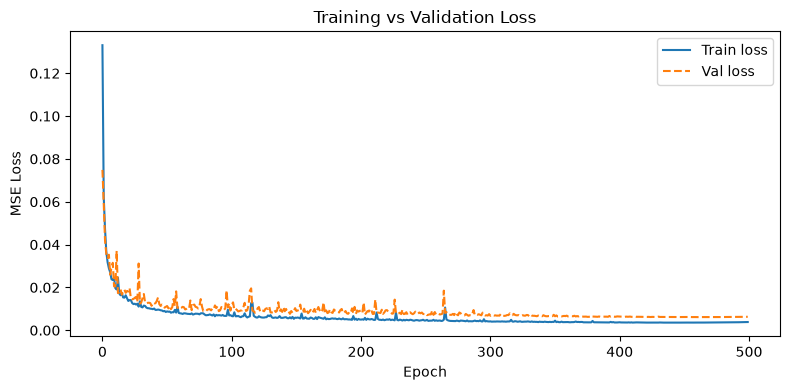

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses,   label='Val loss', linestyle='--')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.tight_layout(); plt.savefig('data/shrink_and_perturb/training_loss.png', dpi=120); plt.show()

---
## Step 6 — Evaluate on Test Rollouts 💻☁️

A low validation loss means the model predicts expert actions accurately on unseen data — but that's not the same as the robot actually being able to run. When deployed, small prediction errors **compound** over time: the robot ends up in states it never saw during training, which leads to worse predictions, which leads to worse states, and so on.

The true test is to **roll the learned policy out in the environment** and measure the total reward it earns. We compare this against the expert over `NUM_EVAL_TRAJ` fresh episodes (the **test set**).

In [8]:
NUM_EVAL_TRAJ = 30
model = model.cpu().eval()

#hi jake can u see thiss

expert_returns  = []
learned_returns = []

rng = np.random.default_rng(0)
for _ in tqdm(range(NUM_EVAL_TRAJ), desc='Evaluating'):
    seed = int(rng.integers(0, 2**31))

    def eval_reward(eval_policy, reward_array):
        env = gym.make(ENV_NAME)
        obs, _ = env.reset(seed=seed)
        ep_reward = 0.0
        for _ in range(MAX_TIMESTEPS):
            action = eval_policy(obs)
            obs, reward, done, truncated, _ = env.step(action)
            ep_reward += reward
            if done or truncated: break
        env.close()
        reward_array.append(ep_reward)

    # ── expert rollout ───────────────────────────────────────
    # eval_reward(lambda obs : policy.predict(obs, deterministic=True), expert_returns)
    env = gym.make(ENV_NAME)
    obs, _ = env.reset(seed=seed)
    ep_reward = 0.0
    for _ in range(MAX_TIMESTEPS):
        action, _ = policy.predict(obs, deterministic=True)
        obs, reward, done, truncated, _ = env.step(action)
        ep_reward += reward
        if done or truncated: break
    env.close()
    expert_returns.append(ep_reward)

    # ── learned policy rollout ───────────────────────────────
    def learned_eval_procedure(obs):
        obs_t  = torch.tensor(normalize_obs(obs), dtype=torch.float32).unsqueeze(0)
        action = model(obs_t).squeeze(0).numpy()
        return action

    # eval_reward(learned_eval_procedure, learned_returns)
    env = gym.make(ENV_NAME)
    obs, _ = env.reset(seed=seed)
    ep_reward = 0.0
    with torch.no_grad():
        for _ in range(MAX_TIMESTEPS):
            obs_t  = torch.tensor(normalize_obs(obs), dtype=torch.float32).unsqueeze(0)
            action = model(obs_t).squeeze(0).numpy()
            obs, reward, done, truncated, _ = env.step(action)
            ep_reward += reward
            if done or truncated: break
    env.close()
    learned_returns.append(ep_reward)

expert_returns  = np.array(expert_returns)
learned_returns = np.array(learned_returns)

print(f'Expert  avg return: {expert_returns.mean():.1f} +/- {expert_returns.std():.1f}')
print(f'Learned avg return: {learned_returns.mean():.1f} +/- {learned_returns.std():.1f}')
reward_gap = (expert_returns.mean() - learned_returns.mean()) / abs(expert_returns.mean())
print(f'Normalised reward gap: {reward_gap:.1%}')

Evaluating: 100%|██████████████████████████████████████████████████████████████████████| 30/30 [00:07<00:00,  4.20it/s]

Expert  avg return: 3029.4 +/- 31.5
Learned avg return: 2736.4 +/- 601.7
Normalised reward gap: 9.7%


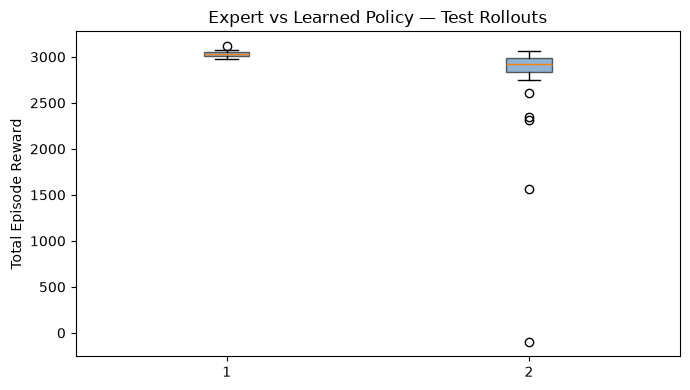

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([expert_returns, learned_returns],
           label=['Expert', 'Learned (ours)'], patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_ylabel('Total Episode Reward'); ax.set_title('Expert vs Learned Policy — Test Rollouts')
plt.tight_layout(); plt.savefig('data/shrink_and_perturb/eval_rewards.png', dpi=120); plt.show()

---
# Part 2 — Fine-tuning the IL Policy with PPO (CleanRL)

We now take the behavior-cloned policy from Part 1 and **fine-tune it with
reinforcement learning** using **[CleanRL](https://docs.cleanrl.dev/rl-algorithms/ppo/)'s
reference `ppo_continuous_action.py`** — a widely-used, well-tested PPO implementation —
adapted to run inside a notebook (no `argparse`, no command-line script).

**Warm-starting from IL.** The PPO actor (`actor_mean`) uses the *same* architecture as
the IL `MLP`, so we copy the trained IL weights straight into it
(`agent.actor_mean.load_state_dict(model.net.state_dict())`). PPO therefore starts from
the IL policy's competence instead of from scratch. Four things are needed to keep that
warm start from being destroyed the instant RL begins:

1. **Small initial exploration noise** (`actor_logstd = -3.0`, std ≈ 0.05). A large
   initial std drowns the IL policy's coordinated gait in random torques and the very
   first rollouts collapse to ~0/negative reward.
2. **No `NormalizeReward`.** Its cold-start running std amplifies early rewards into huge,
   noisy advantages that wreck the warm-started actor — we train on the raw reward scale.
3. **Value-target normalization.** Raw returns are large (V ≈ 9/(1−0.99) ≈ 900), so a
   fresh critic regressing them has an enormous, non-converging loss. We keep a running
   mean/std of returns and have the critic predict the *normalized* return, denormalizing
   whenever we need a value on the true reward scale for advantages.
4. **Critic warm-up + correct truncation handling.** Before any joint update we freeze the
   actor and train only the critic to predict returns under the IL policy. And because
   HalfCheetah episodes end by a 1000-step *time limit* (truncation), not a real terminal
   state, GAE bootstraps through truncation — it only zeroes the future value on true
   `terminated` (which HalfCheetah never emits).

At the end, we compare all three: **Expert (SAC)**, **IL (behavior cloning)**, and
**PPO (IL + RL fine-tuning)**.

Same environment throughout: `HalfCheetah-v5`.

> ⚠️ If you're on Colab, make sure you're still on a **T4 GPU** runtime (Runtime → Change
> runtime type). With the default settings below (500k steps, 4 parallel envs) expect
> roughly 10-20 min on GPU.


In [10]:
# ── PPO (CleanRL) imports ─────────────────────────────────────────────────────
import random
import time
from types import SimpleNamespace
from collections import deque

from torch.distributions.normal import Normal

try:
    from torch.utils.tensorboard import SummaryWriter
    TENSORBOARD_AVAILABLE = True
except Exception:
    TENSORBOARD_AVAILABLE = False
    print('TensorBoard not available — training will still run, just without logging to runs/.')

print('Ready for RL training.')


Ready for RL training.


### Step A — PPO Hyperparameters

Same knobs as CleanRL's script, just set directly as a `SimpleNamespace` instead of
parsed from the command line (there's no command line in a notebook). `total_timesteps`
is trimmed down from CleanRL's usual 1M default to keep runtime reasonable — bump it up
if you want a more polished policy and don't mind a longer run.


In [11]:
%pip install wandb

Note: you may need to restart the kernel to use updated packages.


In [11]:
args = SimpleNamespace(
    exp_name        = 'ppo_halfcheetah',
    seed            = 714,
    torch_deterministic = True,
    cuda            = True,
    track           = True,          # set True + `pip install wandb` for W&B logging
    wandb_project_name = 'cleanRL',
    wandb_entity    = None,
    capture_video   = False,

    # ── Environment ──────────────────────────────────────────────────────────
    env_id          = ENV_NAME,       # 'HalfCheetah-v5', from Step 1

    # ── Rollout collection ───────────────────────────────────────────────────
    total_timesteps = 500_000,        # CleanRL default is 1_000_000; trimmed for speed
    num_envs        = 4,
    num_steps       = 2048,

    # ── PPO update ───────────────────────────────────────────────────────────
    learning_rate   = 3e-4,
    anneal_lr       = True,
    gamma           = 0.99,
    gae_lambda      = 0.95,
    num_minibatches = 32,
    update_epochs   = 10,
    norm_adv        = True,
    clip_coef       = 0.2,
    clip_vloss      = True,
    ent_coef        = 0.0,
    vf_coef         = 0.5,
    max_grad_norm   = 0.5,
    target_kl       = None,
)
args.batch_size = int(args.num_envs * args.num_steps)
args.minibatch_size = int(args.batch_size // args.num_minibatches)
num_updates = args.total_timesteps // args.batch_size

print(f'Batch size: {args.batch_size:,}   Minibatch size: {args.minibatch_size}')
print(f'Total updates: {num_updates}   ({args.total_timesteps/1e6:.2f}M env steps)')

Batch size: 8,192   Minibatch size: 256
Total updates: 61   (0.50M env steps)


### Step B — Vectorized Environments and the Actor-Critic

`make_env` builds one wrapped HalfCheetah environment (action clipping, episode-stats
tracking). Note we **do not** use `NormalizeReward` here: with a warm-started actor but a
cold critic, the reward normalizer's tiny initial running-std amplifies early rewards and
helps blow up the warm start, so we train on the raw reward scale.

`Agent` is CleanRL's actor-critic: the **actor** (`actor_mean`) matches the IL `MLP`
architecture exactly, so we can load the IL weights straight into it; the **critic** is a
separate small MLP (randomly initialized, warmed up in Step C). `actor_logstd` starts
small (std ≈ 0.05) so the first rollouts stay close to the deterministic IL policy.


In [12]:
def make_env(env_id, seed, idx, capture_video, run_name, gamma):
    """Env wrappers matching the CleanRL reference, EXCEPT observation
    normalization uses our FIXED demo-derived stats (OBS_MEAN/OBS_STD) instead of
    a running NormalizeObservation. That way the PPO env feeds the IL actor
    exactly the normalized-obs distribution it was trained on (warm start valid),
    while everything else — action clip, reward normalization, reward clip — is
    the standard reference recipe that keeps values ~O(1) and PPO stable."""
    def thunk():
        if capture_video and idx == 0:
            env = gym.make(env_id, render_mode='rgb_array')
        else:
            env = gym.make(env_id)
        env = gym.wrappers.FlattenObservation(env)
        env = gym.wrappers.RecordEpisodeStatistics(env)
        if capture_video and idx == 0:
            env = gym.wrappers.RecordVideo(env, f'videos/{run_name}')
        env = gym.wrappers.ClipAction(env)
        # Fixed observation normalization (== the IL training transform).
        env = gym.wrappers.TransformObservation(
            env, lambda obs: normalize_obs(obs), observation_space=env.observation_space)
        # Reference reward handling: normalize + clip -> rewards/values ~O(1).
        env = gym.wrappers.NormalizeReward(env, gamma=gamma)
        env = gym.wrappers.TransformReward(env, lambda reward: np.clip(reward, -10, 10))
        env.action_space.seed(seed)
        return env
    return thunk


def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    torch.nn.init.orthogonal_(layer.weight, std)
    torch.nn.init.constant_(layer.bias, bias_const)
    return layer


class Agent(nn.Module):
    """Actor-critic identical to the CleanRL reference (64-unit Tanh MLPs,
    orthogonal init). The actor_mean matches the IL `MLP.net` exactly, so the IL
    weights load straight in. actor_logstd starts at -3.0 (std~0.05) instead of
    the reference's 0.0, to keep the first rollouts close to the deterministic IL
    policy (the whole point of warm-starting)."""
    def __init__(self, envs):
        super().__init__()
        obs_dim = np.array(envs.single_observation_space.shape).prod()
        act_dim = np.prod(envs.single_action_space.shape)
        self.critic = nn.Sequential(
            layer_init(nn.Linear(obs_dim, 64)),
            nn.Tanh(),
            layer_init(nn.Linear(64, 64)),
            nn.Tanh(),
            layer_init(nn.Linear(64, 1), std=1.0),
        )
        self.actor_mean = nn.Sequential(
            layer_init(nn.Linear(obs_dim, 64)),
            nn.Tanh(),
            layer_init(nn.Linear(64, 64)),
            nn.Tanh(),
            layer_init(nn.Linear(64, act_dim), std=0.01),
        )
        self.actor_logstd = nn.Parameter(torch.ones(1, act_dim) * -3.0)

    def get_value(self, x):
        return self.critic(x)

    def get_action_and_value(self, x, action=None):
        action_mean = self.actor_mean(x)
        action_logstd = self.actor_logstd.expand_as(action_mean)
        action_std = torch.exp(action_logstd)
        probs = Normal(action_mean, action_std)
        if action is None:
            action = probs.sample()
        return action, probs.log_prob(action).sum(1), probs.entropy().sum(1), self.critic(x)


print('make_env, layer_init, Agent defined.')

make_env, layer_init, Agent defined.


### Step C — Train! 🏋️

This is CleanRL's training loop almost unchanged, with two adjustments for the notebook:

1. No `argparse` / `if __name__ == "__main__":` — it just runs in this cell.
2. The episode-logging check is updated from `infos["final_info"]` to
   `infos["episode"]` / `infos["_episode"]`, since Gymnasium 1.x changed how vectorized
   environments report per-episode stats (the old key doesn't exist any more, which was
   silently swallowing every episode-return print/log).


In [13]:
run_name = f'{args.env_id}__{args.exp_name}__{args.seed}__{int(time.time())}'

if args.track:
    import wandb
    wandb.init(project=args.wandb_project_name, entity=args.wandb_entity,
               sync_tensorboard=True, config=vars(args), name=run_name,
               monitor_gym=True, save_code=True)

if TENSORBOARD_AVAILABLE:
    writer = SummaryWriter(f'runs/{run_name}')
    writer.add_text('hyperparameters',
        '|param|value|\n|-|-|\n%s' % ('\n'.join([f'|{k}|{v}|' for k, v in vars(args).items()])))
else:
    class _NoOpWriter:
        def add_scalar(self, *a, **k): pass
        def add_text(self, *a, **k): pass
        def close(self): pass
    writer = _NoOpWriter()

# TRY NOT TO MODIFY: seeding
random.seed(args.seed)
np.random.seed(args.seed)
torch.manual_seed(args.seed)
torch.backends.cudnn.deterministic = args.torch_deterministic

device = torch.device('cuda' if torch.cuda.is_available() and args.cuda else 'cpu')
print(f'Training on: {device}')

# env setup
envs = gym.vector.SyncVectorEnv(
    [make_env(args.env_id, args.seed + i, i, args.capture_video, run_name, args.gamma) for i in range(args.num_envs)]
)
assert isinstance(envs.single_action_space, gym.spaces.Box), 'only continuous action space is supported'

agent = Agent(envs).to(device)

# ── Warm start: load the IL policy weights into the PPO actor ────────────────
# The IL MLP.net and agent.actor_mean have identical architecture, so this is a
# direct state_dict copy. Prefer the in-memory `model`; fall back to disk.
try:
    agent.actor_mean.load_state_dict(model.net.state_dict())
    print('Loaded IL weights into PPO actor (from in-memory model).')
except NameError:
    _il = MLP(obs_dim=int(np.array(envs.single_observation_space.shape).prod()),
              act_dim=int(np.prod(envs.single_action_space.shape)), hidden_size=64)
    _il.load_state_dict(torch.load('il_policy.pt', map_location=device))
    agent.actor_mean.load_state_dict(_il.net.state_dict())
    print('Loaded IL weights into PPO actor (from il_policy.pt).')

# Quick sanity: deterministic rollout of the loaded actor in the (wrapped) env.
with torch.no_grad():
    _o, _ = envs.reset(seed=args.seed + 123)
    _o = torch.Tensor(_o).to(device); _tot = np.zeros(args.num_envs)
    for _ in range(1000):
        _a = agent.actor_mean(_o)
        _o2, _r, _te, _tr, _ = envs.step(_a.cpu().numpy())
        _tot += _r; _o = torch.Tensor(_o2).to(device)
    print(f'[sanity] loaded-actor deterministic return/env (normalized-reward scale): {_tot.mean():.1f}')

optimizer = optim.Adam(agent.parameters(), lr=args.learning_rate, eps=1e-5)

# ALGO Logic: Storage setup
obs      = torch.zeros((args.num_steps, args.num_envs) + envs.single_observation_space.shape).to(device)
actions  = torch.zeros((args.num_steps, args.num_envs) + envs.single_action_space.shape).to(device)
logprobs = torch.zeros((args.num_steps, args.num_envs)).to(device)
rewards  = torch.zeros((args.num_steps, args.num_envs)).to(device)
dones    = torch.zeros((args.num_steps, args.num_envs)).to(device)
values   = torch.zeros((args.num_steps, args.num_envs)).to(device)

# TRY NOT TO MODIFY: start the game
global_step = 0
start_time = time.time()
next_obs, _ = envs.reset(seed=args.seed)
next_obs = torch.Tensor(next_obs).to(device)
next_done = torch.zeros(args.num_envs).to(device)

episodic_returns_rl = []
recent_returns = deque(maxlen=20)

pbar = tqdm(range(1, num_updates + 1), desc='PPO training')
for update in pbar:
    if args.anneal_lr:
        frac = 1.0 - (update - 1.0) / num_updates
        optimizer.param_groups[0]['lr'] = frac * args.learning_rate

    for step in range(0, args.num_steps):
        global_step += 1 * args.num_envs
        obs[step] = next_obs
        dones[step] = next_done

        with torch.no_grad():
            action, logprob, _, value = agent.get_action_and_value(next_obs)
            values[step] = value.flatten()
        actions[step] = action
        logprobs[step] = logprob

        next_obs, reward, terminations, truncations, infos = envs.step(action.cpu().numpy())
        next_done = np.logical_or(terminations, truncations)
        rewards[step] = torch.tensor(reward).to(device).view(-1)
        next_obs, next_done = torch.Tensor(next_obs).to(device), torch.Tensor(next_done).to(device)

        # Gymnasium 1.x reports finished episodes via "episode"/"_episode".
        if 'episode' in infos:
            for i, finished in enumerate(infos['_episode']):
                if finished:
                    ep_ret = float(infos['episode']['r'][i]); ep_len = int(infos['episode']['l'][i])
                    episodic_returns_rl.append(ep_ret); recent_returns.append(ep_ret)
                    writer.add_scalar('charts/episodic_return', ep_ret, global_step)
                    writer.add_scalar('charts/episodic_length', ep_len, global_step)

    if recent_returns:
        pbar.set_postfix({'steps': f'{global_step/1e6:.2f}M', 'ret': f'{np.mean(recent_returns):.0f}'})

    # bootstrap value if not done  (reference GAE, verbatim)
    with torch.no_grad():
        next_value = agent.get_value(next_obs).reshape(1, -1)
        advantages = torch.zeros_like(rewards).to(device)
        lastgaelam = 0
        for t in reversed(range(args.num_steps)):
            if t == args.num_steps - 1:
                nextnonterminal = 1.0 - next_done
                nextvalues = next_value
            else:
                nextnonterminal = 1.0 - dones[t + 1]
                nextvalues = values[t + 1]
            delta = rewards[t] + args.gamma * nextvalues * nextnonterminal - values[t]
            advantages[t] = lastgaelam = delta + args.gamma * args.gae_lambda * nextnonterminal * lastgaelam
        returns = advantages + values

    # flatten the batch
    b_obs = obs.reshape((-1,) + envs.single_observation_space.shape)
    b_logprobs = logprobs.reshape(-1)
    b_actions = actions.reshape((-1,) + envs.single_action_space.shape)
    b_advantages = advantages.reshape(-1)
    b_returns = returns.reshape(-1)
    b_values = values.reshape(-1)

    # Optimizing the policy and value network (reference, verbatim)
    b_inds = np.arange(args.batch_size)
    clipfracs = []
    for epoch in range(args.update_epochs):
        np.random.shuffle(b_inds)
        for start in range(0, args.batch_size, args.minibatch_size):
            end = start + args.minibatch_size
            mb_inds = b_inds[start:end]

            _, newlogprob, entropy, newvalue = agent.get_action_and_value(b_obs[mb_inds], b_actions[mb_inds])
            logratio = newlogprob - b_logprobs[mb_inds]
            ratio = logratio.exp()

            with torch.no_grad():
                old_approx_kl = (-logratio).mean()
                approx_kl = ((ratio - 1) - logratio).mean()
                clipfracs += [((ratio - 1.0).abs() > args.clip_coef).float().mean().item()]

            mb_advantages = b_advantages[mb_inds]
            if args.norm_adv:
                mb_advantages = (mb_advantages - mb_advantages.mean()) / (mb_advantages.std() + 1e-8)

            pg_loss1 = -mb_advantages * ratio
            pg_loss2 = -mb_advantages * torch.clamp(ratio, 1 - args.clip_coef, 1 + args.clip_coef)
            pg_loss = torch.max(pg_loss1, pg_loss2).mean()

            newvalue = newvalue.view(-1)
            if args.clip_vloss:
                v_loss_unclipped = (newvalue - b_returns[mb_inds]) ** 2
                v_clipped = b_values[mb_inds] + torch.clamp(
                    newvalue - b_values[mb_inds], -args.clip_coef, args.clip_coef)
                v_loss_clipped = (v_clipped - b_returns[mb_inds]) ** 2
                v_loss_max = torch.max(v_loss_unclipped, v_loss_clipped)
                v_loss = 0.5 * v_loss_max.mean()
            else:
                v_loss = 0.5 * ((newvalue - b_returns[mb_inds]) ** 2).mean()

            entropy_loss = entropy.mean()
            loss = pg_loss - args.ent_coef * entropy_loss + v_loss * args.vf_coef

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(agent.parameters(), args.max_grad_norm)
            optimizer.step()

        if args.target_kl is not None and approx_kl > args.target_kl:
            break

    y_pred, y_true = b_values.cpu().numpy(), b_returns.cpu().numpy()
    var_y = np.var(y_true)
    explained_var = np.nan if var_y == 0 else 1 - np.var(y_true - y_pred) / var_y

    writer.add_scalar('charts/learning_rate', optimizer.param_groups[0]['lr'], global_step)
    writer.add_scalar('losses/value_loss', v_loss.item(), global_step)
    writer.add_scalar('losses/policy_loss', pg_loss.item(), global_step)
    writer.add_scalar('losses/entropy', entropy_loss.item(), global_step)
    writer.add_scalar('losses/approx_kl', approx_kl.item(), global_step)
    writer.add_scalar('losses/clipfrac', np.mean(clipfracs), global_step)
    writer.add_scalar('losses/explained_variance', explained_var, global_step)

envs.close()
writer.close()

torch.save(agent.state_dict(), 'ppo_halfcheetah.pt')
print(f'\nTraining complete in {(time.time() - start_time)/60:.1f} min. Saved ppo_halfcheetah.pt')

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\jakew\_netrc.
wandb: Currently logged in as: jwidmann (jwidmann-pennsylvania-governor-s-school-for-the-sciences) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Training on: cpu
Loaded IL weights into PPO actor (from in-memory model).
[sanity] loaded-actor deterministic return/env (normalized-reward scale): 47.0


PPO training: 100%|█████████████████████████████████████████████| 61/61 [04:54<00:00,  4.82s/it, steps=0.50M, ret=9123]



Training complete in 4.9 min. Saved ppo_halfcheetah.pt


wandb: WARNING Artifact "source-cleanRL-plasticity_shrink_and_perturb.ipynb" already exists with the same content. No new version will be created.


In [15]:
%pip install tensorboard

   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/5.5 MB ? eta -:--:--
   ----- ---------------------------------- 0.8/5.5 MB 2.4 MB/s eta 0:00:02
   ----------- ---------------------------- 1.6/5.5 MB 2.8 MB/s eta 0:00:02
   ----------------- ---------------------- 2.4/5.5 MB 3.1 MB/s eta 0:00:02
   ---------------------- ----------------- 3.1/5.5 MB 3.3 MB/s eta 0:00:01
   ------------------------------ --------- 4.2/5.5 MB 3.6 MB/s eta 0:00:01
   ------------------------------------ --- 5.0/5.5 MB 3.8 MB/s eta 0:00:01
   ---------------------------------------  5.5/5.5 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 5.5/5.5 MB 3.3 MB/s  0:00:01
   ---------------------------------------- 0.0/5.0 MB ? eta -:--:--
   ---- ----------------------------------- 0.5/5.0 MB 5.0 MB/s eta 0:00:01
   ------------ --------------------------- 1.6/5.0 MB 4.9 MB/s eta 0:00:01
   ----------------------- ---------

### Step D — Evaluate and Compare: Expert vs IL vs PPO

We evaluate all three policies — **Expert (SAC)**, **IL (behavior cloning)**, and
**PPO (IL + RL fine-tuning)** — with a *single* shared `evaluate()` function over the
same **1000-step** episode horizon and the same seeds. This is the horizon the PPO
training curve already used, so the training plot, the IL baseline line, and this bar
chart are all finally on the same scale. (Earlier the IL policy was rolled out separately
over only 300 steps, which is why it appeared as ~10k on the training plot but ~2k in its
own eval — same reward math, different number of steps.)


In [14]:
# ══════════════════════════════════════════════════════════════════
# ONE shared evaluator for all three policies.
# ──────────────────────────────────────────────────────────────────
# Previously the IL policy and the PPO agent were rolled out by two different
# functions with different horizons (IL used MAX_TIMESTEPS=300, the PPO training
# curve logged full 1000-step episodes) — that\'s why the IL policy looked like
# ~10k on the training plot but ~2k in the IL eval. The reward *math* was fine in
# both; they just summed over different numbers of steps. Here we evaluate
# Expert, IL, and PPO with the SAME function and the SAME horizon so every number
# and plot is directly comparable.
# ══════════════════════════════════════════════════════════════════
EVAL_MAX_STEPS = 1000   # HalfCheetah\'s native episode length (matches the PPO training curve)

def evaluate(step_fn, env_id, num_episodes=10, max_steps=EVAL_MAX_STEPS, seed=999):
    """Roll out step_fn(obs)->action deterministically and return per-episode total rewards."""
    returns = []
    for ep in range(num_episodes):
        env = gym.make(env_id)
        obs, _ = env.reset(seed=seed + ep)
        ep_ret = 0.0
        for _ in range(max_steps):
            action = step_fn(obs)
            obs, reward, terminated, truncated, _ = env.step(action)
            ep_ret += reward
            if terminated or truncated:
                break
        env.close()
        returns.append(ep_ret)
    return np.array(returns)

# per-policy action functions (all deterministic / mean action)
def expert_step_fn(obs):
    action, _ = policy.predict(obs, deterministic=True)
    return action

def il_step_fn(obs):
    with torch.no_grad():
        obs_t = torch.tensor(normalize_obs(obs), dtype=torch.float32).unsqueeze(0)
        return model(obs_t).squeeze(0).numpy()

def ppo_step_fn(obs):
    with torch.no_grad():
        obs_t = torch.tensor(normalize_obs(obs), dtype=torch.float32, device=device).unsqueeze(0)
        return agent.actor_mean(obs_t).squeeze(0).cpu().numpy()

agent.eval()
expert_returns  = evaluate(expert_step_fn, ENV_NAME, num_episodes=NUM_EVAL_TRAJ)
learned_returns = evaluate(il_step_fn,     ENV_NAME, num_episodes=NUM_EVAL_TRAJ)
ppo_returns     = evaluate(ppo_step_fn,    ENV_NAME, num_episodes=NUM_EVAL_TRAJ)
agent.train()

print(f'(all evaluated over {EVAL_MAX_STEPS}-step episodes, same seeds)\n')
print(f'Expert avg return: {expert_returns.mean():.1f} +/- {expert_returns.std():.1f}')
print(f'IL     avg return: {learned_returns.mean():.1f} +/- {learned_returns.std():.1f}')
print(f'PPO    avg return: {ppo_returns.mean():.1f} +/- {ppo_returns.std():.1f}')


(all evaluated over 1000-step episodes, same seeds)

Expert avg return: 11481.7 +/- 69.8
IL     avg return: 7293.5 +/- 4434.1
PPO    avg return: 8408.4 +/- 4708.5


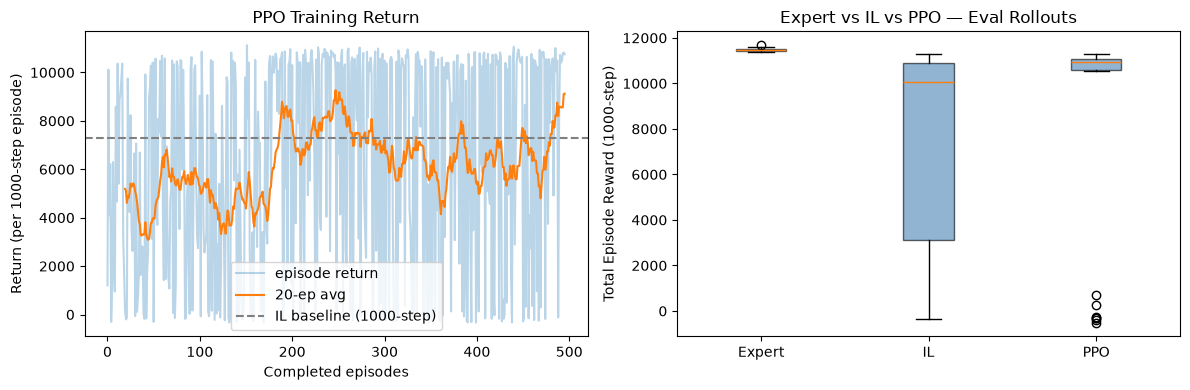

NameError: name 'policy_losses_rl' is not defined

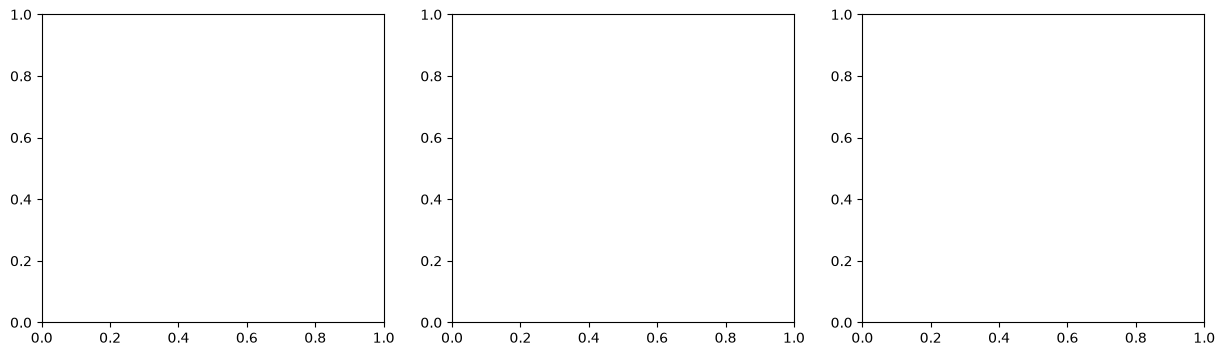

In [15]:
# ── Row 1: training return + eval comparison ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(episodic_returns_rl, alpha=0.3, label='episode return')
W = 20
if len(episodic_returns_rl) >= W:
    smooth = np.convolve(episodic_returns_rl, np.ones(W) / W, mode='valid')
    axes[0].plot(range(W - 1, len(episodic_returns_rl)), smooth, label=f'{W}-ep avg')
# IL baseline is now measured over the SAME 1000-step horizon as the training
# episodes (see the shared evaluate() in Step D), so this line is comparable.
axes[0].axhline(learned_returns.mean(), color='gray', linestyle='--', label='IL baseline (1000-step)')
axes[0].set_xlabel('Completed episodes'); axes[0].set_ylabel('Return (per 1000-step episode)')
axes[0].set_title('PPO Training Return'); axes[0].legend()

axes[1].boxplot(
    [expert_returns, learned_returns, ppo_returns],
    tick_labels=['Expert', 'IL', 'PPO'], patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
)
axes[1].set_ylabel('Total Episode Reward (1000-step)')
axes[1].set_title('Expert vs IL vs PPO — Eval Rollouts')

plt.tight_layout()
plt.savefig('data/shrink_and_perturb/il_vs_ppo_comparison.png', dpi=120)
plt.show()

# ── Row 2: PPO optimization diagnostics (policy loss, value loss, approx KL) ──
fig2, ax2 = plt.subplots(1, 3, figsize=(15, 4))

ax2[0].plot(policy_losses_rl, color='tab:blue')
ax2[0].set_xlabel('Update'); ax2[0].set_ylabel('Policy loss')
ax2[0].set_title('Policy (actor) loss'); ax2[0].axhline(0, color='gray', lw=0.6)

ax2[1].plot(value_losses_rl, color='tab:orange')
ax2[1].set_xlabel('Update'); ax2[1].set_ylabel('Value loss (normalized target)')
ax2[1].set_title('Value (critic) loss')

ax2[2].plot(approx_kls_rl, color='tab:green')
ax2[2].axhline(args.target_kl if args.target_kl is not None else 0.0,
               color='red', linestyle='--', lw=0.8,
               label=('target_kl' if args.target_kl is not None else None))
ax2[2].set_xlabel('Update'); ax2[2].set_ylabel('Approx KL')
ax2[2].set_title('Policy update size (approx KL)')
if args.target_kl is not None:
    ax2[2].legend()

plt.tight_layout()
plt.savefig('ppo_losses.png', dpi=120)
plt.show()

print(f'IL  eval return:  {learned_returns.mean():.1f} +/- {learned_returns.std():.1f}')
print(f'PPO eval return:  {ppo_returns.mean():.1f} +/- {ppo_returns.std():.1f}')
print(f'Delta (PPO - IL): {ppo_returns.mean() - learned_returns.mean():+.1f}')
